# Porównanie algorytmów: Genetyczny vs Pszczeli

Eksperymenty porównawcze z użyciem wspólnej populacji początkowej.

In [1]:
import time
import random
import copy
from dataclasses import dataclass, field
from abc import ABC, abstractmethod

import matplotlib.pyplot as plt

from problem_solution import Problem, Solution
from genetic_new_hope import GeneticSolver
from bee_solver import BeeSolver

## Klasy abstrakcji

In [2]:
def generate_initial_population(problem: Problem, population_size: int) -> list[list[int]]:
    keys = list(problem.situations.keys())
    population = []
    for _ in range(population_size):
        order = list(keys)
        random.shuffle(order)
        population.append(order)
    return population

In [8]:
@dataclass
class ExperimentResult:
    """Wynik pojedynczego uruchomienia algorytmu."""
    algorithm_name: str
    final_cost: float
    elapsed_time: float
    is_correct: bool
    best_costs: list[float]
    avg_costs: list[float]
    solution: Solution

    def summary(self) -> str:
        return (
            f"{self.algorithm_name}:\n"
            f"  Czas:      {self.elapsed_time:.3f} s\n"
            f"  Koszt:     {self.final_cost}\n"
            f"  Poprawny:  {self.is_correct}"
        )
    
    @staticmethod
    def combine(results: list["ExperimentResult"]) -> "ExperimentResult":
        algorithm_name = results[0].algorithm_name
        final_cost = min(result.final_cost for result in results)
        elapsed_time = sum(result.elapsed_time for result in results)
        is_correct = all(result.is_correct for result in results)
        best_costs = [min(results[j].best_costs[i] for j in range(len(results))) for i in range(len(results[0].best_costs))]
        avg_costs = [sum(results[j].avg_costs[i] for j in range(len(results)))/len(results) for i in range(len(results[0].avg_costs))]
        solution = results[0].solution
        return ExperimentResult(algorithm_name, final_cost, elapsed_time, is_correct, best_costs, avg_costs, solution)


In [4]:
class SolverAdapter(ABC):
    """Abstrakcja opakowująca dowolny solver w jednolity interfejs."""

    def __init__(self, name: str):
        self.name = name

    @abstractmethod
    def run(self, problem: Problem, generations: int, initial_population: list[list[int]]) -> ExperimentResult:
        ...


class GeneticAdapter(SolverAdapter):
    def __init__(self, name: str = "Genetic", mutation_rate: float = 0.25, mutate_mode: str = "swap", crossover_mode: str = "keep_splice"):
        super().__init__(name)
        self.mutation_rate = mutation_rate
        self.mutate_mode = mutate_mode
        self.crossover_mode = crossover_mode

    def run(self, problem: Problem, generations: int, initial_population: list[list[int]]) -> ExperimentResult:
        pop_size = len(initial_population)
        solver = GeneticSolver(
            problem,
            population_size=pop_size,
            mutation_rate=self.mutation_rate,
            mutate_mode=self.mutate_mode,
            crossover_mode=self.crossover_mode,
        )
        start = time.perf_counter()
        solution = solver.evolve(
            generations=generations,
            initial_population=initial_population,
            save_history=True,
            verbose=False,
        )
        solution.calculate_cost_function()
        elapsed = time.perf_counter() - start

        return ExperimentResult(
            algorithm_name=self.name,
            final_cost=solution.get_cost(),
            elapsed_time=elapsed,
            is_correct=solution.is_correct(),
            best_costs=[h[0] for h in solver.history],
            avg_costs=[h[1] for h in solver.history],
            solution=solution,
        )


class BeeAdapter(SolverAdapter):
    def __init__(self, name: str = "Bee", good_elite_cnt: int = 10, elite_cnt: int = 3, local_elite_cnt: int = 10, local_good_cnt: int = 4):
        super().__init__(name)
        self.good_elite_cnt = good_elite_cnt
        self.elite_cnt = elite_cnt
        self.local_elite_cnt = local_elite_cnt
        self.local_good_cnt = local_good_cnt

    def run(self, problem: Problem, generations: int, initial_population: list[list[int]]) -> ExperimentResult:
        pop_size = len(initial_population)
        solver = BeeSolver(
            problem,
            bees_cnt=pop_size,
            good_elite_cnt=self.good_elite_cnt,
            elite_cnt=self.elite_cnt,
            local_elite_cnt=self.local_elite_cnt,
            local_good_cnt=self.local_good_cnt,
        )
        start = time.perf_counter()
        solution = solver.evolve(
            iterations=generations,
            initial_population=initial_population,
            verbose=False,
        )
        elapsed = time.perf_counter() - start

        return ExperimentResult(
            algorithm_name=self.name,
            final_cost=solution.get_cost(),
            elapsed_time=elapsed,
            is_correct=solution.is_correct(),
            best_costs=[h[0] for h in solver.history],
            avg_costs=[h[1] for h in solver.history],
            solution=solution,
        )

In [10]:
@dataclass
class ExperimentConfig:
    """Konfiguracja pojedynczego eksperymentu."""
    name: str
    num_vertices: int = 60
    num_edges: int = 400
    min_weight: int = 1
    max_weight: int = 10
    num_situations: int = 20
    min_car_amount: int = 2
    max_car_amount: int = 5
    seed: int = 42
    generations: int = 40
    population_size: int = 50
    adapters: list[SolverAdapter] = field(default_factory=list)
    no_simulations: int =  1

    def build_problem(self) -> Problem:
        return Problem.random(
            num_vertices=self.num_vertices,
            num_edges=self.num_edges,
            min_weight=self.min_weight,
            max_weight=self.max_weight,
            num_situations=self.num_situations,
            min_car_amount=self.min_car_amount,
            max_car_amount=self.max_car_amount,
            seed=self.seed,
        )

In [6]:
class Experiment:
    """Uruchamia adaptery na wspólnej populacji i zbiera wyniki."""

    def __init__(self, config: ExperimentConfig):
        self.config = config
        self.problem = config.build_problem()
        assert self.problem.check_validity(), "Problem jest niepoprawny!"
        self.initial_population = generate_initial_population(self.problem, config.population_size)
        self.results: list[ExperimentResult] = []

    def run(self) -> list[ExperimentResult]:
        print(f"=== {self.config.name} ===")
        print(f"Populacja początkowa: {self.config.population_size} osobników")
        print(f"Generacje: {self.config.generations}\n")
        self.results = []
        for adapter in self.config.adapters:
            print(f"Uruchamiam: {adapter.name} ...")
            results = []
            for _ in range(self.config.no_simulations):
                results.append(adapter.run(self.problem, self.config.generations, self.initial_population))
            result = ExperimentResult.combine(results)
            self.results.append(result)
            print(result.summary())
            print()
        return self.results

    def plot_best_costs(self, figsize=(10, 6)):
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
        markers = ['o', 's', '^', 'D', 'v', 'P', 'X']

        fig, ax = plt.subplots(figsize=figsize)
        for i, r in enumerate(self.results):
            ax.plot(
                r.best_costs,
                label=f"{r.algorithm_name} (koszt: {r.final_cost})",
                color=colors[i % len(colors)],
                marker=markers[i % len(markers)],
                markersize=4,
            )
        ax.set_title(f"{self.config.name} — best cost", fontsize=14)
        ax.set_xlabel("Generacja", fontsize=12)
        ax.set_ylabel("Koszt (best)", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(fontsize=11)
        ax.set_xticks(range(0, self.config.generations + 2, max(1, self.config.generations // 10)))
        fig.tight_layout()
        plt.show()

    def plot_avg_costs(self, figsize=(10, 6)):
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
        markers = ['o', 's', '^', 'D', 'v', 'P', 'X']

        fig, ax = plt.subplots(figsize=figsize)
        for i, r in enumerate(self.results):
            ax.plot(
                r.avg_costs,
                label=f"{r.algorithm_name} (avg final: {r.avg_costs[-1]:.0f})",
                color=colors[i % len(colors)],
                marker=markers[i % len(markers)],
                markersize=4,
                linestyle='--',
            )
        ax.set_title(f"{self.config.name} — avg cost", fontsize=14)
        ax.set_xlabel("Generacja", fontsize=12)
        ax.set_ylabel("Koszt (avg)", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(fontsize=11)
        ax.set_xticks(range(0, self.config.generations + 2, max(1, self.config.generations // 10)))
        fig.tight_layout()
        plt.show()

    def summary_table(self):
        print(f"\n{'Algorytm':<30} | {'Czas [s]':>10} | {'Koszt':>10} | {'Poprawny':>10}")
        print("-" * 70)
        for r in self.results:
            print(f"{r.algorithm_name:<30} | {r.elapsed_time:>10.3f} | {r.final_cost:>10} | {str(r.is_correct):>10}")

## Eksperyment 1 — Domyślne parametry

Porównanie genetycznego i pszczelego z domyślnymi parametrami.

=== Domyślne parametry ===
Populacja początkowa: 50 osobników
Generacje: 40

Uruchamiam: Genetic (swap, keep_splice) ...
Genetic (swap, keep_splice):
  Czas:      33.381 s
  Koszt:     2293
  Poprawny:  True

Uruchamiam: Bee (domyślny) ...
Bee (domyślny):
  Czas:      65.756 s
  Koszt:     2176
  Poprawny:  True



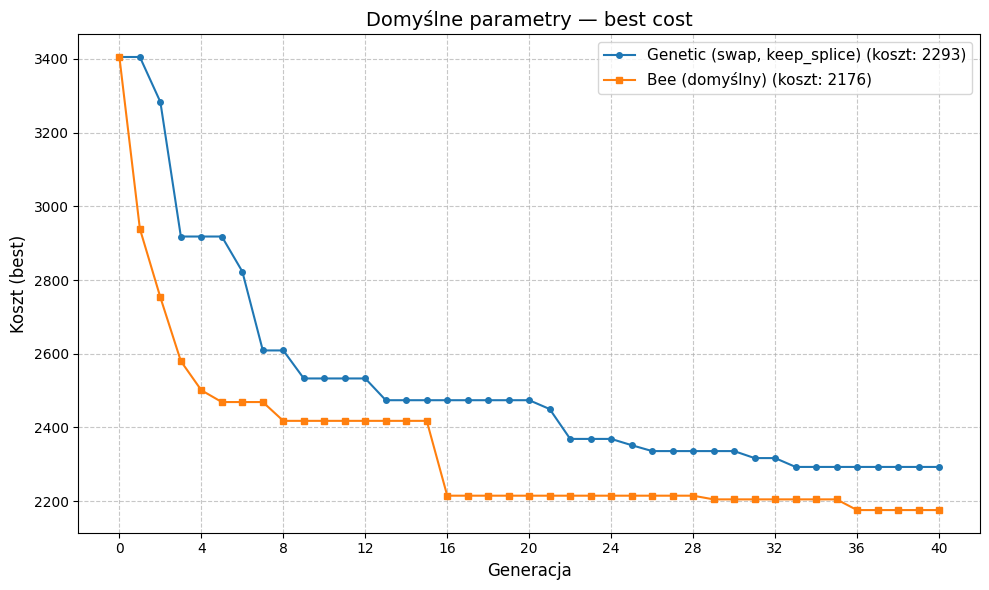

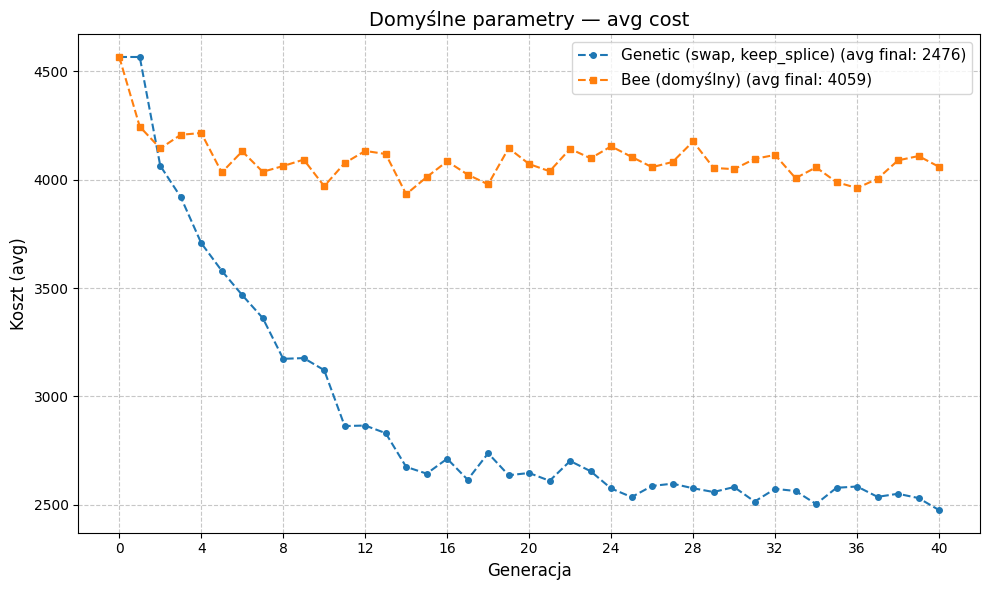


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
Genetic (swap, keep_splice)    |     33.381 |       2293 |       True
Bee (domyślny)                 |     65.756 |       2176 |       True


In [ ]:
exp1 = Experiment(ExperimentConfig(
    name="Domyślne parametry",
    seed=42,
    generations=15,
    population_size=50,
    no_simulations=3,
    adapters=[
        GeneticAdapter(name="Genetic (swap, keep_splice)", mutation_rate=0.25),
        BeeAdapter(name="Bee (domyślny)", good_elite_cnt=10, elite_cnt=3, local_elite_cnt=10, local_good_cnt=4),
    ],
))

exp1.run()
exp1.plot_best_costs()
exp1.plot_avg_costs()
exp1.summary_table()

## Eksperyment 2 — Większa populacja

70 osobników, 50 generacji.

=== Większa populacja (seed=78) ===
Populacja początkowa: 70 osobników
Generacje: 50

Uruchamiam: Genetic (mr=0.25) ...
Genetic (mr=0.25):
  Czas:      28.600 s
  Koszt:     5189
  Poprawny:  True

Uruchamiam: Bee (elite=3, good=10) ...
Bee (elite=3, good=10):
  Czas:      49.572 s
  Koszt:     5533
  Poprawny:  True



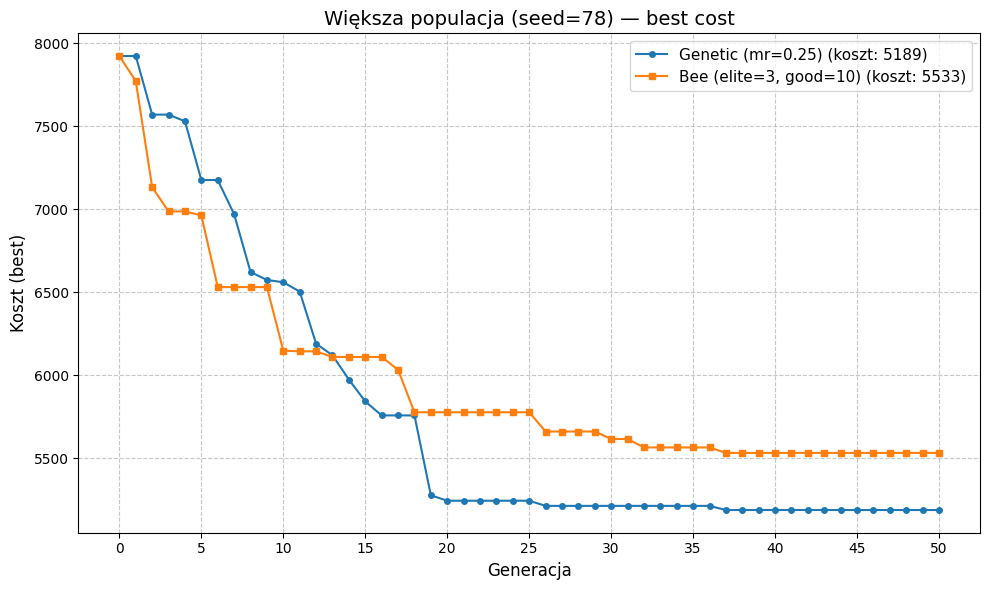


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
Genetic (mr=0.25)              |     28.600 |       5189 |       True
Bee (elite=3, good=10)         |     49.572 |       5533 |       True


In [8]:
exp2 = Experiment(ExperimentConfig(
    name="Większa populacja (seed=78)",
    seed=78,
    generations=50,
    population_size=70,
    adapters=[
        GeneticAdapter(name="Genetic (mr=0.25)", mutation_rate=0.25),
        BeeAdapter(name="Bee (elite=3, good=10)", good_elite_cnt=10, elite_cnt=3, local_elite_cnt=10, local_good_cnt=4),
    ],
))

exp2.run()
exp2.plot_best_costs()
exp2.summary_table()

## Eksperyment 3 — Duża populacja, wysoka mutacja

100 osobników, mutation_rate=0.5.

=== Duża populacja, wysoka mutacja (seed=67) ===
Populacja początkowa: 100 osobników
Generacje: 50

Uruchamiam: Genetic (mr=0.5) ...
Genetic (mr=0.5):
  Czas:      42.918 s
  Koszt:     3684
  Poprawny:  True

Uruchamiam: Bee (elite=3, good=7) ...
Bee (elite=3, good=7):
  Czas:      51.978 s
  Koszt:     3862
  Poprawny:  True



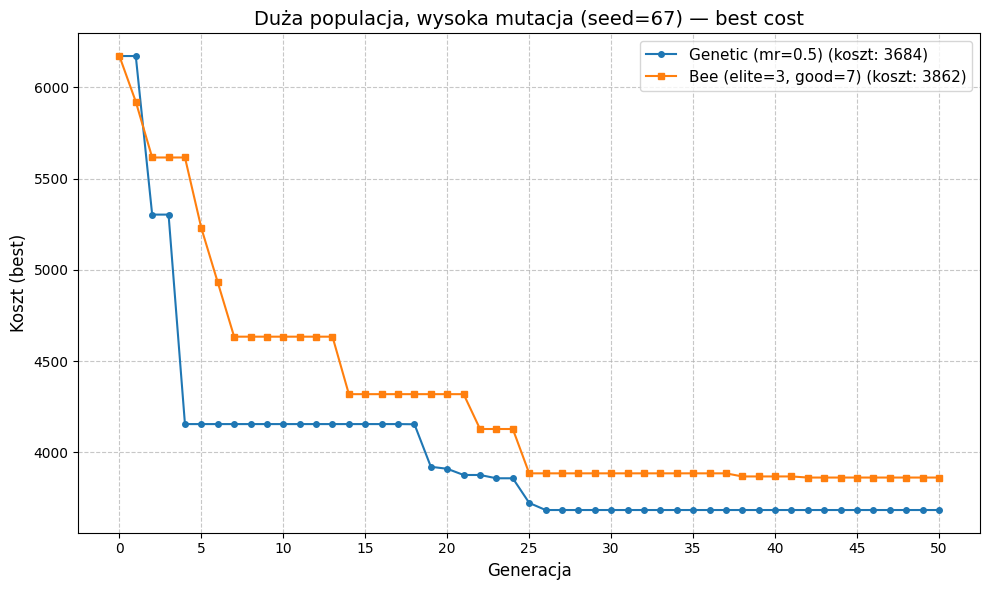


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
Genetic (mr=0.5)               |     42.918 |       3684 |       True
Bee (elite=3, good=7)          |     51.978 |       3862 |       True


In [9]:
exp3 = Experiment(ExperimentConfig(
    name="Duża populacja, wysoka mutacja (seed=67)",
    seed=67,
    generations=50,
    population_size=100,
    adapters=[
        GeneticAdapter(name="Genetic (mr=0.5)", mutation_rate=0.5),
        BeeAdapter(name="Bee (elite=3, good=7)", good_elite_cnt=7, elite_cnt=3, local_elite_cnt=7, local_good_cnt=3),
    ],
))

exp3.run()
exp3.plot_best_costs()
exp3.summary_table()

## Eksperyment 4 — Porównanie trybów mutacji (Genetic)

Swap vs reinsert przy tej samej populacji początkowej.

=== Tryby mutacji genetycznego ===
Populacja początkowa: 50 osobników
Generacje: 40

Uruchamiam: Genetic swap (mr=0.5) ...
Genetic swap (mr=0.5):
  Czas:      16.334 s
  Koszt:     2058
  Poprawny:  True

Uruchamiam: Genetic reinsert (mr=0.5) ...
Genetic reinsert (mr=0.5):
  Czas:      15.696 s
  Koszt:     2131
  Poprawny:  True

Uruchamiam: Bee (referencja) ...
Bee (referencja):
  Czas:      31.076 s
  Koszt:     2185
  Poprawny:  True



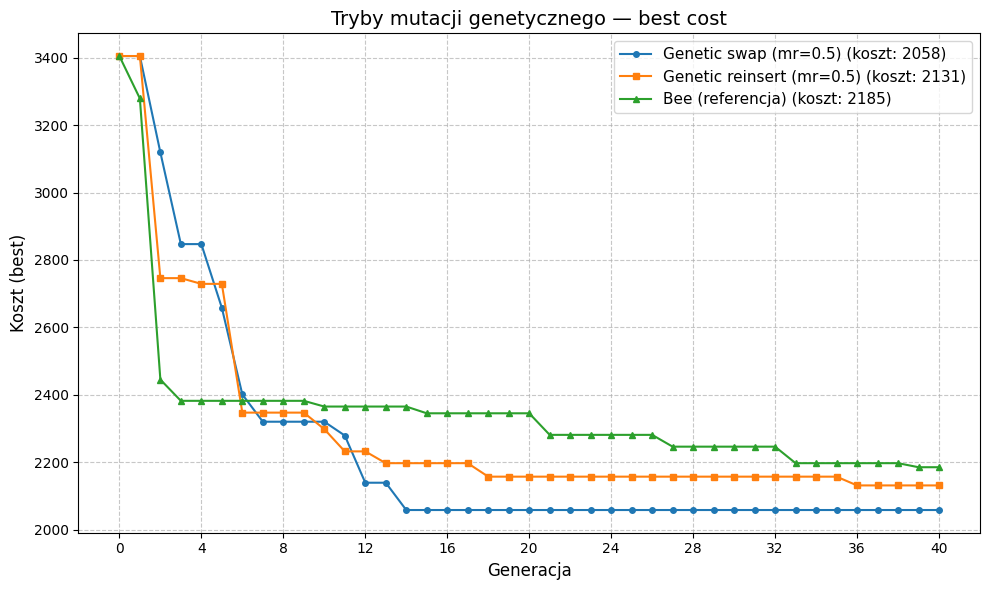


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
Genetic swap (mr=0.5)          |     16.334 |       2058 |       True
Genetic reinsert (mr=0.5)      |     15.696 |       2131 |       True
Bee (referencja)               |     31.076 |       2185 |       True


In [10]:
exp4 = Experiment(ExperimentConfig(
    name="Tryby mutacji genetycznego",
    seed=42,
    generations=40,
    population_size=50,
    adapters=[
        GeneticAdapter(name="Genetic swap (mr=0.5)",    mutation_rate=0.5, mutate_mode="swap"),
        GeneticAdapter(name="Genetic reinsert (mr=0.5)", mutation_rate=0.5, mutate_mode="reinsert"),
        BeeAdapter(name="Bee (referencja)", good_elite_cnt=10, elite_cnt=3, local_elite_cnt=10, local_good_cnt=4),
    ],
))

exp4.run()
exp4.plot_best_costs()
exp4.summary_table()

## Eksperyment 5 — Porównanie trybów crossover (Genetic)

keep_splice vs swap_order.

=== Tryby crossover genetycznego ===
Populacja początkowa: 50 osobników
Generacje: 40

Uruchamiam: Genetic keep_splice ...
Genetic keep_splice:
  Czas:      15.946 s
  Koszt:     2474
  Poprawny:  True

Uruchamiam: Genetic swap_order ...
Genetic swap_order:
  Czas:      16.934 s
  Koszt:     2267
  Poprawny:  True

Uruchamiam: Bee (referencja) ...
Bee (referencja):
  Czas:      30.214 s
  Koszt:     2137
  Poprawny:  True



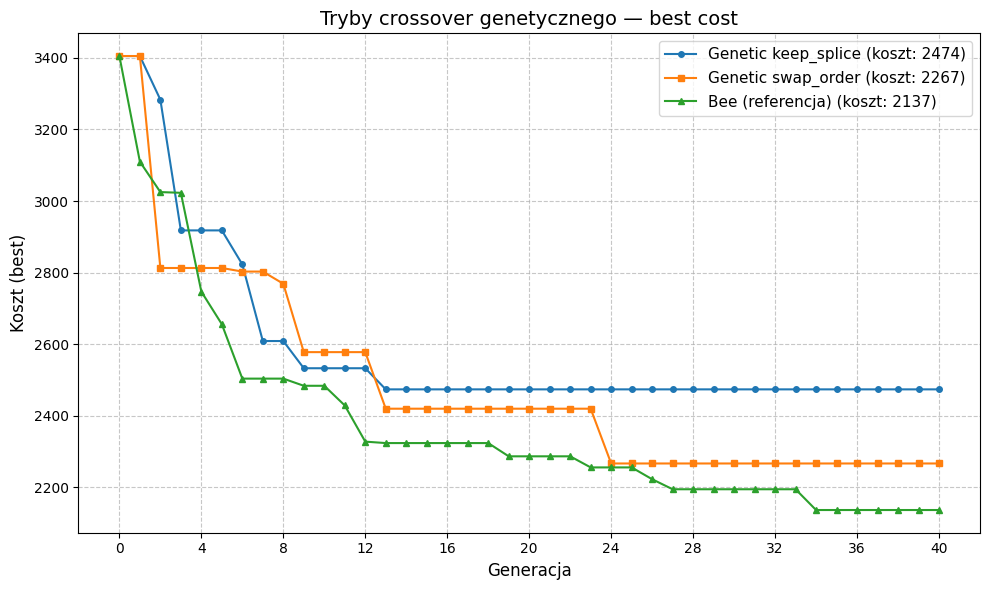


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
Genetic keep_splice            |     15.946 |       2474 |       True
Genetic swap_order             |     16.934 |       2267 |       True
Bee (referencja)               |     30.214 |       2137 |       True


In [11]:
exp5 = Experiment(ExperimentConfig(
    name="Tryby crossover genetycznego",
    seed=42,
    generations=40,
    population_size=50,
    adapters=[
        GeneticAdapter(name="Genetic keep_splice",  mutation_rate=0.25, crossover_mode="keep_splice"),
        GeneticAdapter(name="Genetic swap_order",    mutation_rate=0.25, crossover_mode="swap_order"),
        BeeAdapter(name="Bee (referencja)"),
    ],
))

exp5.run()
exp5.plot_best_costs()
exp5.summary_table()

## Eksperyment 6 — Strategie pszczele

Różne konfiguracje algorytmu pszczelego przy wspólnej populacji.

=== Strategie pszczele ===
Populacja początkowa: 50 osobników
Generacje: 40

Uruchamiam: Genetic (referencja) ...
Genetic (referencja):
  Czas:      16.084 s
  Koszt:     2474
  Poprawny:  True

Uruchamiam: Bee zbalansowany ...
Bee zbalansowany:
  Czas:      31.132 s
  Koszt:     2135
  Poprawny:  True

Uruchamiam: Bee dużo losowości ...
Bee dużo losowości:
  Czas:      16.299 s
  Koszt:     2407
  Poprawny:  True

Uruchamiam: Bee silna elita ...
Bee silna elita:
  Czas:      51.494 s
  Koszt:     2170
  Poprawny:  True

Uruchamiam: Bee rój ...
Bee rój:
  Czas:      66.947 s
  Koszt:     2135
  Poprawny:  True



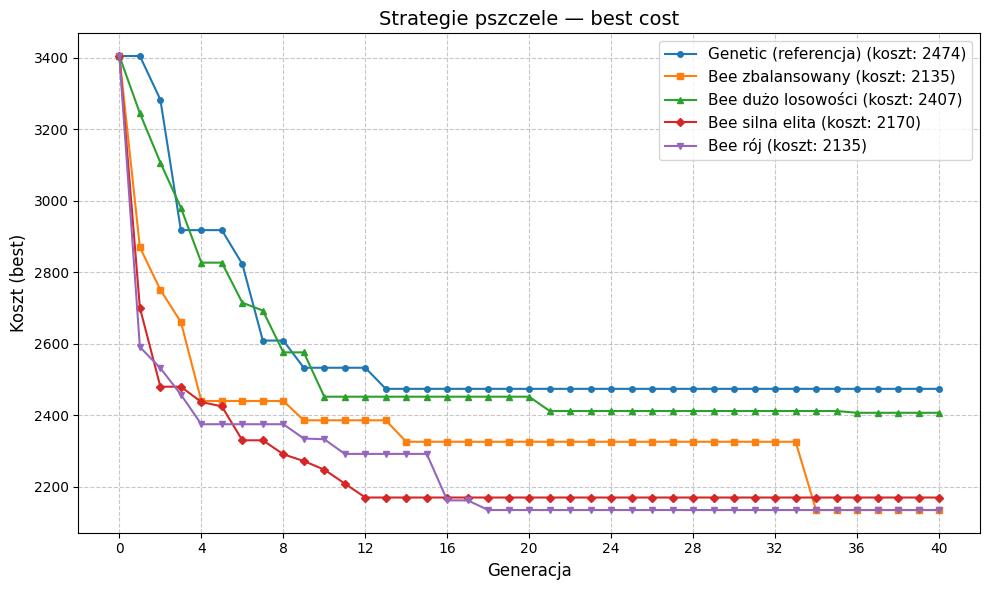


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
Genetic (referencja)           |     16.084 |       2474 |       True
Bee zbalansowany               |     31.132 |       2135 |       True
Bee dużo losowości             |     16.299 |       2407 |       True
Bee silna elita                |     51.494 |       2170 |       True
Bee rój                        |     66.947 |       2135 |       True


In [12]:
exp6 = Experiment(ExperimentConfig(
    name="Strategie pszczele",
    seed=42,
    generations=40,
    population_size=50,
    adapters=[
        GeneticAdapter(name="Genetic (referencja)", mutation_rate=0.25),
        BeeAdapter(name="Bee zbalansowany",          good_elite_cnt=10, elite_cnt=3, local_elite_cnt=10, local_good_cnt=4),
        BeeAdapter(name="Bee dużo losowości",        good_elite_cnt=5,  elite_cnt=2, local_elite_cnt=2,  local_good_cnt=1),
        BeeAdapter(name="Bee silna elita",           good_elite_cnt=3,  elite_cnt=3, local_elite_cnt=40, local_good_cnt=0),
        BeeAdapter(name="Bee rój",                   good_elite_cnt=15, elite_cnt=5, local_elite_cnt=20, local_good_cnt=8),
    ],
))

exp6.run()
exp6.plot_best_costs()
exp6.summary_table()

## Eksperyment 7 — Wpływ mutation rate (Genetic)

Porównanie różnych wartości mutation_rate.

=== Wpływ mutation rate ===
Populacja początkowa: 50 osobników
Generacje: 40

Uruchamiam: Genetic mr=0.0 ...
Genetic mr=0.0:
  Czas:      15.556 s
  Koszt:     2357
  Poprawny:  True

Uruchamiam: Genetic mr=0.1 ...
Genetic mr=0.1:
  Czas:      15.574 s
  Koszt:     2427
  Poprawny:  True

Uruchamiam: Genetic mr=0.25 ...
Genetic mr=0.25:
  Czas:      15.469 s
  Koszt:     2307
  Poprawny:  True

Uruchamiam: Genetic mr=0.5 ...
Genetic mr=0.5:
  Czas:      15.473 s
  Koszt:     2107
  Poprawny:  True

Uruchamiam: Genetic mr=0.75 ...
Genetic mr=0.75:
  Czas:      18.611 s
  Koszt:     2154
  Poprawny:  True

Uruchamiam: Genetic mr=1.0 ...
Genetic mr=1.0:
  Czas:      17.709 s
  Koszt:     2110
  Poprawny:  True

Uruchamiam: Bee (referencja) ...
Bee (referencja):
  Czas:      32.440 s
  Koszt:     2235
  Poprawny:  True



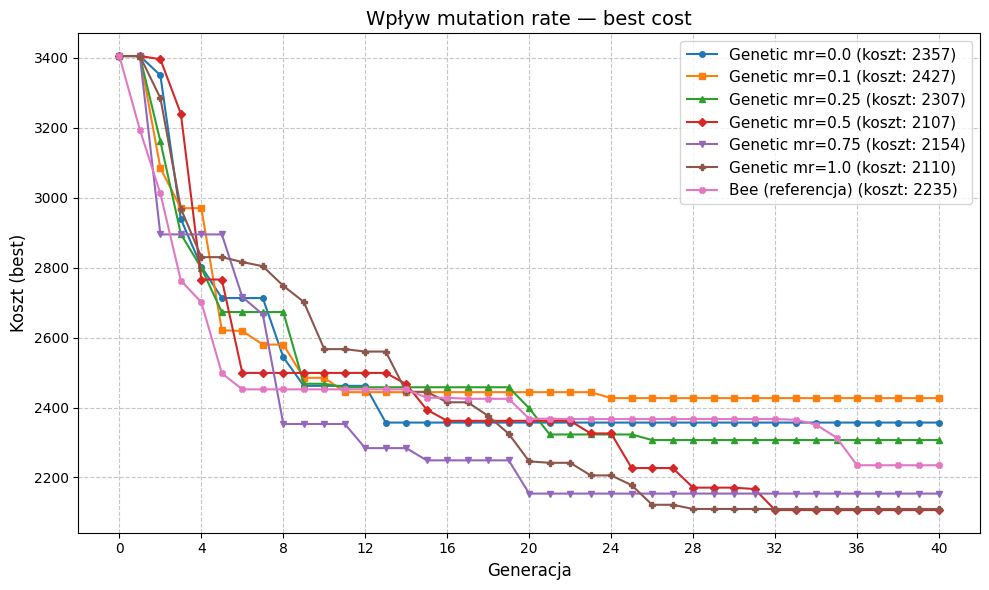


Algorytm                       |   Czas [s] |      Koszt |   Poprawny
----------------------------------------------------------------------
Genetic mr=0.0                 |     15.556 |       2357 |       True
Genetic mr=0.1                 |     15.574 |       2427 |       True
Genetic mr=0.25                |     15.469 |       2307 |       True
Genetic mr=0.5                 |     15.473 |       2107 |       True
Genetic mr=0.75                |     18.611 |       2154 |       True
Genetic mr=1.0                 |     17.709 |       2110 |       True
Bee (referencja)               |     32.440 |       2235 |       True


In [13]:
adapters_mr = []
for mr in [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]:
    adapters_mr.append(GeneticAdapter(name=f"Genetic mr={mr}", mutation_rate=mr))
adapters_mr.append(BeeAdapter(name="Bee (referencja)"))

exp7 = Experiment(ExperimentConfig(
    name="Wpływ mutation rate",
    seed=42,
    generations=40,
    population_size=50,
    adapters=adapters_mr,
))

exp7.run()
exp7.plot_best_costs()
exp7.summary_table()